In [1]:
import torch
import matplotlib.pyplot as plt
import subprocess
import pathlib
import sys
import pandas as pd
import numpy as np
# Add the parent directory to the system path to import ismrmrd_utils
sys.path.append(str(pathlib.Path("/home/t-aatalik/psirnet").resolve()))
sys.path.append(str(pathlib.Path("/home/t-aatalik/psirnet/src").resolve()))
sys.path.append(str(pathlib.Path("/home/t-aatalik/psirnet/scripts").resolve()))
from src.pl_data_module import PSIRNetDataModule
from src.data import read_buffer
from src.ismrmrd_utils import Message, IsmrmrdSource
from src.math_utils import expand, reduce, itfftc, tfftc
from scripts.main import PSIRNetLightning
from src.models import PSIRNet
from collections import Counter
from typing import List
from tqdm import tqdm
from data import process_single_item

In [ ]:
lge_filtered_most_common = pd.read_csv("../csv_files/large_files/lge_filtered_most_common.csv")
headers = lge_filtered_most_common["header"].tolist()

In [ ]:
encoding_dict = vars(vars(read_raw_buffer(headers[0])[0])['encoding'][0])
encoding_dict = {k: v for k, v in encoding_dict.items() if v is not None}
encoding_dict = np.array(encoding_dict, dtype=object)
np.savez('dict_data.npz', encoding_dict=encoding_dict)

In [ ]:
loaded = np.load('../results/npz_files/86008_436.npz', allow_pickle=True)
loaded['encoding_dict'].item()

In [ ]:
data_module = PSIRNetDataModule(
    train_batch_size=1,
    val_batch_size=1,
    test_batch_size=8,
    train_csv = '/home/t-aatalik/psirnet/csv_files/train.csv',
    val_csv = '/home/t-aatalik/psirnet/csv_files/val.csv',
    test_csv = '/home/t-aatalik/psirnet/csv_files/test.csv',
)

data_module.setup(stage="test")
test_buffer_df = pd.read_csv('/home/t-aatalik/psirnet/csv_files/test.csv')

In [ ]:
import torch
import numpy as np
from torch import nn


def load_model(pt_path: str) -> nn.Module:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    try:
        model = torch.jit.load(pt_path, map_location=device)
    except Exception as e:
        print(f"Error loading model: {e}")
        raise e
    return model

def infer(
    ir_kspace: np.ndarray, 
    pd_kspace: np.ndarray, 
    sens_maps: np.ndarray,
    model: nn.Module,
) -> np.ndarray:
    """
    Perform inference using the PSIRNet model.
    NumPy arrays are excepted in the following format:
    B: batch dimension (number of slices in a multi-slice acquisition)
    C: coil dimension (number of coils in the multi-coil acquisition)
    Ro: readout dimension
    Pe: phase encoding dimension
    Args:
        ir_kspace (np.ndarray): Single average IR k-space data.
            Complex float of shape (B, C, Ro, Pe) 
        pd_kspace (np.ndarray): Single average PD k-space data.
            Complex float of shape (B, C, Ro, Pe) 
        sens_maps (np.ndarray): Sensitivity maps.
            Complex float of shape (B, C, Ro, Pe) 
        model (nn.Module): Trained PSIRNet model.
    
    Returns:
        np.ndarray: Reconstructed real-valued PSIR image.
        dtype is float32 and shape is (B, H, W) where H and W
        are the height and width of the image.
    """
    # Perform checks
    assert ir_kspace.shape == pd_kspace.shape == sens_maps.shape, \
        "k-space and sensitivity maps must have the same shape"
    assert ir_kspace.dtype == pd_kspace.dtype == sens_maps.dtype, \
        "k-space and sensitivity maps must have the same dtype"
    assert ir_kspace.ndim == 4, "k-space must be 4D (B, C, Ro, Pe)"
    assert ir_kspace.dtype == np.complex64, "k-space must be complex float (np.complex64)"

    # Prepare inputs
    ir_kspace = torch.tensor(ir_kspace, dtype=torch.complex64, device=model.device)
    pd_kspace = torch.tensor(pd_kspace, dtype=torch.complex64, device=model.device)
    sens_maps = torch.tensor(sens_maps, dtype=torch.complex64, device=model.device)
    mask = (ir_kspace != 0)[:, 0:1, ...]  # B, 1, Ro, Pe undersampling mask

    # Perform inference and move the reconstruction to CPU
    # Also squeeze the unit channel dimension and convert to NumPy
    output = model(ir_kspace, pd_kspace, mask, sens_maps)
    output = output.squeeze().cpu().numpy()
    return output

In [ ]:
checkpoint_path = "/home/t-aatalik/psirnet/checkpoints/PSIRNet.ckpt"
model = PSIRNetLightning.load_from_checkpoint(checkpoint_path, num_cascades=12, sens_chans=32, chans=96)
model.eval()  # Set to evaluation mode
model.cuda()  # Move to GPU

In [ ]:
file = np.load('/home/t-aatalik/psirnet/results/npz_files/86008_432.npz')
stacked = file['stacked']
vmins = file['vmins']
vmaxs = file['vmaxs']

In [ ]:
df = pd.read_csv("/home/t-aatalik/psirnet/csv_files/large_files/lge_filtered_most_common.csv")
df_test = df[238425:]
# df_test = df_test[df_test.file_name.apply(lambda x: x.split('_')[0] == 'WB')]
# df_test = df_test.sort_values(by=['num_slices'], ascending=False)
df_test = df_test.reset_index(drop=True)
# df_test = df_test[df_test['num_averages'] == 8].reset_index(drop=True)

In [ ]:
num_slice = 0
session = df[df['session_id'] == df_test.iloc[24].session_id]
row = session.iloc[0]
batch_idx = (test_buffer_df['buffer'] == eval(row['combined_buffer'])[0]).idxmax() + num_slice
dataset = data_module.test_dataloader().dataset
batch = process_single_item(dataset[batch_idx])

ir_masked_kspace = batch.ir_kspace[None].cuda()
pd_masked_kspace = batch.pd_kspace[None].cuda()
min_target = batch.min_target[None].cuda()
max_target = batch.max_target[None].cuda()
mask = batch.mask[None].cuda()
sens_maps = batch.sens_maps[None].cuda()

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
# Script the model
with torch.no_grad():
    scripted = torch.jit.script(
        model.model,
        example_inputs=[(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)]
    )
    scripted = torch.jit.freeze(scripted)
    scripted = torch.jit.optimize_for_inference(scripted)
    torch.jit.save(scripted, '../checkpoints/PSIRNet.pt')

In [ ]:
from torch import nn
def load_model(pt_path: str) -> nn.Module:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    try:
        model = torch.jit.load(pt_path, map_location=device)
    except Exception as e:
        print(f"Error loading model: {e}")
        raise e
    return model

scripted_model = load_model('/home/t-aatalik/psirnet/checkpoints/PSIRNet.pt')

In [ ]:
with torch.no_grad():
    out_1 = model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)
    out_2 = scripted(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)
assert torch.allclose(out_1, out_2, atol=1e-12), "Outputs from the model and scripted model do not match"

In [ ]:
num_slice = 0
session = df[df['session_id'] == df_test.iloc[24].session_id]
row = session.iloc[5]
batch_idx = (test_buffer_df['buffer'] == eval(row['combined_buffer'])[0]).idxmax() + num_slice
dataset = data_module.test_dataloader().dataset
batch = process_single_item(dataset[batch_idx])

ir_masked_kspace = batch.ir_kspace[None].cuda()
pd_masked_kspace = batch.pd_kspace[None].cuda()
min_target = batch.min_target[None].cuda()
max_target = batch.max_target[None].cuda()
mask = batch.mask[None].cuda()
sens_maps = batch.sens_maps[None].cuda()

output = scripted_model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)

In [ ]:
df_test

In [ ]:
import pandas as pd 
df = pd.read_csv("/home/t-aatalik/psirnet/csv_files/large_files/lge_filtered_most_common.csv")
df_test = df[238425:]
df_test = df_test.reset_index(drop=True)

num_splits = 8
split_size = len(df_test) // num_splits
remainder = len(df_test) % num_splits

df_test_splits = []
start_idx = 0

for i in range(num_splits):
    # Add 1 extra row to the first 'remainder' splits to handle uneven division
    end_idx = start_idx + split_size + (1 if i < remainder else 0)
    df_test_splits.append(df_test.iloc[start_idx:end_idx].reset_index(drop=True))
    start_idx = end_idx

# Save each split to a separate CSV file
for i, split_df in enumerate(df_test_splits):
    split_df.to_csv(f"/home/t-aatalik/psirnet/results/temp_csv_files/df_test_split_{i}.csv", index=False)
    print(f"Saved split {i} with {len(split_df)} rows to df_test_split_{i}.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

file = np.load("/home/t-aatalik/psirnet/results/npz_files/87097_496.npz")
stacked, vmin, vmax = file['stacked'], file['vmins'], file['vmaxs']
print(f"Number of slices: {stacked.shape[0]}")
h, w = 256, 192
slice = 0
dpi = plt.rcParams['figure.dpi']
fig = plt.figure(figsize=(3*w/dpi, h/dpi), dpi=dpi, frameon=False)
gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax1.imshow(stacked[slice, 0], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
ax1.axis('off')
ax2.imshow(stacked[slice, 1], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
ax2.axis('off')
ax3.imshow(stacked[slice, 2], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
ax3.axis('off')

In [141]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

lge_filtered_most_common = pd.read_csv("../csv_files/large_files/lge_filtered_most_common.csv")
df = lge_filtered_most_common[238425:]
df = df[df['file_name'].apply(lambda x: x.split('_')[0] == 'WB')][['session_id', 'measurement_id']].reset_index(drop=True)

/tmp/ipykernel_850464/700261545.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  lge_filtered_most_common = pd.read_csv("../csv_files/large_files/lge_filtered_most_common.csv")


Number of slices: 13
Number of averages: 12
PAT: 2


(-0.5, 191.5, 255.5, -0.5)

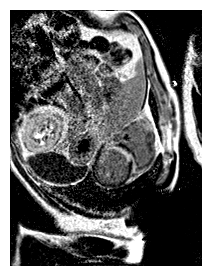

In [177]:
row = df.iloc[6]
measurement_id = row['measurement_id']
session_id = row['session_id']
file = np.load(f"/home/t-aatalik/psirnet/results/npz_files/{session_id}_{measurement_id}.npz", allow_pickle=True)
stacked, vmin, vmax, encoding_size = file['stacked'], file['vmins'], file['vmaxs'], file['encoding_dict'].item()
print(f"Number of slices: {stacked.shape[0]}")
print(f"Number of averages: {encoding_size['encodingLimits'].average.maximum+1}")
print(f"PAT: {encoding_size['parallelImaging'].accelerationFactor.kspace_encoding_step_1}")
h, w = 256, 192
slice = 5
dpi = plt.rcParams['figure.dpi']
fig = plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi, frameon=False)
gs = fig.add_gridspec(1, 1, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(stacked[slice, 1], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
ax1.axis('off')
#plt.savefig('./87097_496_2.png', bbox_inches='tight', pad_inches=0)

Number of slices: 13
Number of averages: 12
PAT: 2


(-0.5, 79.5, 79.5, -0.5)

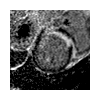

In [219]:
row = df.iloc[6]
measurement_id = row['measurement_id']
session_id = row['session_id']
file = np.load(f"/home/t-aatalik/psirnet/results/npz_files/{session_id}_{measurement_id}.npz", allow_pickle=True)
stacked, vmin, vmax, encoding_size = file['stacked'], file['vmins'], file['vmaxs'], file['encoding_dict'].item()
print(f"Number of slices: {stacked.shape[0]}")
print(f"Number of averages: {encoding_size['encodingLimits'].average.maximum+1}")
print(f"PAT: {encoding_size['parallelImaging'].accelerationFactor.kspace_encoding_step_1}")
h, w = 80, 80
slice = 5
img = stacked[slice, 1, 115:195, 60:140]
dpi = plt.rcParams['figure.dpi']
fig = plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi, frameon=False)
gs = fig.add_gridspec(1, 1, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img, vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
ax1.axis('off')

In [4]:
import os
f = [f for f in os.listdir("../results/png_files/") if f.split('_')[5] == '125']
f.sort()
f

['100832_1947_24_0_2_125_0.png',
 '100832_1949_24_0_2_125_0.png',
 '101121_732_24_0_2_125_0.png',
 '101121_752_24_0_2_125_0.png',
 '101121_753_24_0_2_125_0.png',
 '101121_754_24_0_2_125_0.png',
 '101121_755_24_0_2_125_0.png',
 '101121_756_24_0_2_125_0.png',
 '101121_757_24_0_2_125_0.png',
 '101121_758_24_0_2_125_0.png',
 '101121_759_24_0_2_125_0.png',
 '101121_760_24_0_2_125_0.png',
 '101121_761_24_0_2_125_0.png',
 '101121_762_24_0_2_125_0.png',
 '101154_58_24_0_2_125_0.png',
 '101186_1092_24_0_2_125_0.png',
 '101186_1092_24_0_2_125_1.png',
 '101186_1092_24_0_2_125_2.png',
 '101186_1092_24_0_2_125_3.png',
 '101186_1092_24_0_2_125_4.png',
 '101201_330_24_0_2_125_0.png',
 '101201_330_24_0_2_125_1.png',
 '101201_330_24_0_2_125_2.png',
 '101201_330_24_0_2_125_3.png',
 '101201_330_24_0_2_125_4.png',
 '101201_330_24_0_2_125_5.png',
 '101201_330_24_0_2_125_6.png',
 '101201_337_24_0_2_125_0.png',
 '101201_337_24_0_2_125_1.png',
 '101274_569_24_0_2_125_0.png',
 '101352_885_24_0_2_125_0.png',
 '

In [13]:
Counter([(int(f.split('_')[3]), int(f.split('_')[4]), int(f.split('_')[5])) for f in os.listdir("../results/png_files/")])

Counter({(0, 2, 142): 79177,
         (0, 3, 141): 989,
         (0, 2, 125): 189,
         (0, 2, 138): 134,
         (0, 2, 190): 76,
         (0, 2, 145): 71,
         (0, 2, 141): 3})

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

h, w = 256, 192
dpi = plt.rcParams['figure.dpi']
files = os.listdir('../results/npz_files/')
for fname in tqdm(files):
    file = np.load(f"/home/t-aatalik/psirnet/results/npz_files/{fname}", allow_pickle=True)
    stacked, vmin, vmax, encoding_size = file['stacked'], file['vmins'], file['vmaxs'], file['encoding_dict'].item()
    pat_factor = encoding_size['parallelImaging'].accelerationFactor.kspace_encoding_step_1
    enc_min = encoding_size['encodingLimits'].kspace_encoding_step_1.minimum
    enc_max = encoding_size['encodingLimits'].kspace_encoding_step_1.maximum
    num_averages = encoding_size['encodingLimits'].average.maximum - \
        encoding_size['encodingLimits'].average.minimum + 1
    session_id = fname.split('_')[0]
    measurement_id = fname.split('_')[1].split('.')[0]
    save_fname = f"{session_id}_{measurement_id}_{num_averages}_{enc_min}_{pat_factor}_{enc_max}"
    for slice in range(len(stacked)):
        fig = plt.figure(figsize=(3 * w/dpi, h/dpi), dpi=dpi, frameon=False)
        gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])
        ax1.imshow(stacked[slice, 0], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
        ax1.axis('off')
        ax2.imshow(stacked[slice, 1], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
        ax2.axis('off')
        ax3.imshow(stacked[slice, 2], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
        ax3.axis('off')
        save_slice_name = save_fname + f"_{slice}"
        plt.savefig(f'../results/png_files/{save_slice_name}.png', bbox_inches='tight', pad_inches=0)
        plt.close()

  0%|          | 0/25438 [00:00<?, ?it/s]


In [2]:
save_fname

'103401_55_8_0_2_142'

In [233]:
session_id

'103401'

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import os

files = os.listdir('/home/t-aatalik/psirnet/results/npz_files/')

for files_idx in range(21_800):
    file = np.load(f"/home/t-aatalik/psirnet/results/npz_files/{files[files_idx]}", allow_pickle=True)
    stacked, vmin, vmax, encoding_size = file['stacked'], file['vmins'], file['vmaxs'], file['encoding_dict'].item()
    # if encoding_size['encodingLimits'].average.maximum == 11:
    if encoding_size['parallelImaging'].accelerationFactor.kspace_encoding_step_1 == 3:
        h, w = 256, 192
        dpi = plt.rcParams['figure.dpi']
        for slice in range(stacked.shape[0]):
            fig = plt.figure(figsize=(3 * w/dpi, h/dpi), dpi=dpi, frameon=False)
            gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
            ax1 = fig.add_subplot(gs[0, 0])
            ax2 = fig.add_subplot(gs[0, 1])
            ax3 = fig.add_subplot(gs[0, 2])
            ax1.imshow(stacked[slice, 0], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
            ax1.axis('off')
            ax2.imshow(stacked[slice, 1], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
            ax2.axis('off')
            ax3.imshow(stacked[slice, 2], vmin=vmin[slice], vmax=vmax[slice], cmap='gray', interpolation='none')
            ax3.axis('off')
            plt.savefig(f'../results/png_files/{files[files_idx].split(".")[0]}_{slice}.png', bbox_inches='tight', pad_inches=0)
            plt.close()

2

In [ ]:
num_slice = 0
session = df[df['session_id'] == df_test.iloc[24].session_id]
row = session.iloc[5]
batch_idx = (test_buffer_df['buffer'] == eval(row['combined_buffer'])[0]).idxmax() + num_slice
dataset = data_module.test_dataloader().dataset
batch = process_single_item(dataset[batch_idx])

ir_masked_kspace = batch.ir_kspace[None].cuda()
pd_masked_kspace = batch.pd_kspace[None].cuda()
min_target = batch.min_target[None].cuda()
max_target = batch.max_target[None].cuda()
mask = batch.mask[None].cuda()
sens_maps = batch.sens_maps[None].cuda()
target = batch.target.squeeze()

In [ ]:
session = df[df['session_id'] == df_test.iloc[24].session_id]

In [ ]:
def read_raw_buffer(buffer_id) -> List[Message]:
    """
    Function to read a buffer in single pass
    Args:
        buffer_id (str): The ID of the buffer to read.
    Returns:
        list: A list of messages read from the buffer.
    """
    with subprocess.Popen(
        [f"tyger buffer read {buffer_id}"],
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.DEVNULL
    ) as proc:
        try:
            msg_list = list(
                IsmrmrdSource(proc.stdout).source()  # type: ignore
            )
            proc.wait()
            if proc.returncode != 0:
                raise ValueError(f"Error in {buffer_id}")
            return msg_list
        except Exception:
            proc.kill()
            raise

In [ ]:
h, w = 256, 192
dpi = plt.rcParams['figure.dpi']

row = session.iloc[5]
all_recons = read_raw_buffer(row.recon)
psir_one_rep = []
psir_moco = []
for msg in all_recons[1:]:
    if msg.getHead().image_series_index == 107:
        psir_one_rep.append(msg)
    if msg.getHead().image_series_index == 111:
        psir_moco.append(msg)

assert row.num_averages * row.num_slices == len(psir_one_rep)
psir_one_rep = [
    psir_one_rep[i:i+row.num_averages]
    for i in range(0, len(psir_one_rep), row.num_averages)
]

for num_slice in range(row.num_slices):
    batch_idx = (test_buffer_df['buffer'] == eval(row['combined_buffer'])[0]).idxmax() + num_slice
    dataset = data_module.test_dataloader().dataset
    batch = process_single_item(dataset[batch_idx])

    ir_masked_kspace = batch.ir_kspace[None].cuda()
    pd_masked_kspace = batch.pd_kspace[None].cuda()
    min_target = batch.min_target[None].cuda()
    max_target = batch.max_target[None].cuda()
    mask = batch.mask[None].cuda()
    sens_maps = batch.sens_maps[None].cuda()
    target = batch.target.squeeze()
    candidates = psir_one_rep[num_slice]
    candidates = np.array([c.data.squeeze().transpose().real for c in candidates])
    num_ave = int(np.sum(np.abs(candidates - target.numpy()), axis=(1, 2)).argmin())

    wc = int(psir_moco[num_slice].meta['GADGETRON_WindowCenter'])
    ww = int(psir_moco[num_slice].meta['GADGETRON_WindowWidth'])
    vmin, vmax = wc - ww / 2, wc + ww / 2
    vmin = (vmin - 4096) / 1000
    vmax = (vmax - 4096) / 1000
    with torch.no_grad():
        out = model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)

    out = out.squeeze().cpu()
    fig = plt.figure(figsize=(3*w/dpi, h/dpi), dpi=dpi, frameon=False)
    gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(candidates[num_ave], vmin=1000*vmin+4096, vmax=1000*vmax+4096, cmap="gray")
    ax1.axis('off')
    ax2.imshow(target, vmin=vmin, vmax=vmax, cmap="gray")
    ax2.axis('off')
    ax3.imshow(out, vmin=vmin, vmax=vmax, cmap="gray")
    ax3.axis('off')
    plt.savefig(f"../temp/{batch_idx}.png", bbox_inches='tight', pad_inches=0, dpi=dpi)
    plt.close(fig)

In [ ]:
h, w = 256, 192
dpi = plt.rcParams['figure.dpi']

row = session.iloc[6]
all_recons = read_raw_buffer(row.recon)
psir_one_rep = []
psir_moco = []
for msg in all_recons[1:]:
    if msg.getHead().image_series_index == 107:
        psir_one_rep.append(msg)
    if msg.getHead().image_series_index == 111:
        psir_moco.append(msg)

assert row.num_averages * row.num_slices == len(psir_one_rep)
psir_one_rep = [
    psir_one_rep[i:i+row.num_averages]
    for i in range(0, len(psir_one_rep), row.num_averages)
]

num_slice = 2
batch_idx = (test_buffer_df['buffer'] == eval(row['combined_buffer'])[0]).idxmax() + num_slice
dataset = data_module.test_dataloader().dataset
batch = process_single_item(dataset[batch_idx])

# ir_masked_kspace = batch.ir_kspace[None].cuda()
for ir_avg in range(24):
    ir_masked_kspace = torch.tensor(kspace.data[..., ir_avg, 0, num_slice]).cuda().permute(2, 3, 0, 1)
    pd_masked_kspace = batch.pd_kspace[None].cuda()
    min_target = batch.min_target[None].cuda()
    max_target = batch.max_target[None].cuda()
    mask = batch.mask[None].cuda()
    sens_maps = batch.sens_maps[None].cuda()
    target = batch.target.squeeze()
    candidates = psir_one_rep[num_slice]
    candidates = np.array([c.data.squeeze().transpose().real for c in candidates])
    num_ave = int(np.sum(np.abs(candidates - target.numpy()), axis=(1, 2)).argmin())

    wc = int(psir_moco[num_slice].meta['GADGETRON_WindowCenter'])
    ww = int(psir_moco[num_slice].meta['GADGETRON_WindowWidth'])
    vmin, vmax = wc - ww / 2, wc + ww / 2
    vmin = (vmin - 4096) / 1000
    vmax = (vmax - 4096) / 1000
    with torch.no_grad():
        out = model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps)

    out = out.squeeze().cpu()
    fig = plt.figure(figsize=(3*w/dpi, h/dpi), dpi=dpi, frameon=False)
    gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(candidates[ir_avg], vmin=1000*vmin+4096, vmax=1000*vmax+4096, cmap="gray")
    ax1.axis('off')
    ax2.imshow(target, vmin=vmin, vmax=vmax, cmap="gray")
    ax2.axis('off')
    ax3.imshow(out, vmin=vmin, vmax=vmax, cmap="gray")
    ax3.axis('off')
    plt.savefig(f"../temp/{batch_idx}_{ir_avg}.png", bbox_inches='tight', pad_inches=0, dpi=dpi)
    plt.close(fig)

In [ ]:
h, w = 256, 192
dpi = plt.rcParams['figure.dpi']

for idx, batch in enumerate(data_module.test_dataloader()):
    if idx < 5:
        continue
    ir_masked_kspace = batch.ir_kspace.cuda()
    pd_masked_kspace = batch.pd_kspace.cuda()
    min_target = batch.min_target.cuda()
    max_target = batch.max_target.cuda()
    mask = batch.mask.cuda()
    sens_maps = batch.sens_maps.cuda()
    target = batch.target.squeeze()
    vmin, vmax = torch.quantile(target, 0.05), torch.quantile(target, 0.95)
    with torch.no_grad():
        out = model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps) 
    break

# moco = all_recons[44 * (idx + 1)].data.real.squeeze().transpose()
single = psir_one_rep[8 * idx + 1].data.real.squeeze().transpose()
out = out.squeeze().cpu()
fig = plt.figure(figsize=(3*w/dpi, h/dpi), dpi=dpi, frameon=False)
gs = fig.add_gridspec(1, 3, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

ax1.imshow(single, vmin=1000*vmin+4096, vmax=1000*vmax+4096, cmap="gray")
ax1.axis('off')
ax2.imshow(target, vmin=vmin, vmax=vmax, cmap="gray")
ax2.axis('off')
ax3.imshow(out, vmin=vmin, vmax=vmax, cmap="gray")
ax3.axis('off')

In [ ]:
h, w = 256, 192
dpi = plt.rcParams['figure.dpi']
for idx, batch in enumerate(data_module.test_dataloader()):
    ir_masked_kspace = batch.ir_kspace.cuda()
    pd_masked_kspace = batch.pd_kspace.cuda()
    min_target = batch.min_target.cuda()
    max_target = batch.max_target.cuda()
    mask = batch.mask.cuda()
    sens_maps = batch.sens_maps.cuda()
    target = batch.target.squeeze()
    vmin, vmax = torch.quantile(target, 0.05), torch.quantile(target, 0.95)
    with torch.no_grad():
        out = model(ir_masked_kspace, pd_masked_kspace, mask, sens_maps) 
    out = out.squeeze().cpu()
    fig = plt.figure(figsize=(2*w/dpi, h/dpi), dpi=dpi, frameon=False)
    gs = fig.add_gridspec(1, 2, wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    ax1.imshow(target, vmin=vmin, vmax=vmax, cmap="gray")
    ax1.axis('off')
    ax2.imshow(out, vmin=vmin, vmax=vmax, cmap="gray")
    ax2.axis('off')
    plt.savefig(f"../temp/{idx}.png", bbox_inches='tight', pad_inches=0, dpi=dpi)
    plt.close(fig)

In [ ]:
buffers = pd.read_csv('../csv_files/large_files/lge_filtered_most_common.csv')
buffers = buffers[['session_id', 'measurement_id', 'combined_buffer']]
buffers.loc[:, 'combined_buffer'] = buffers.loc[:, 'combined_buffer'].apply(eval)
buffers = buffers.explode('combined_buffer').reset_index(drop=True)
buffers = buffers.sort_values(by=['session_id', 'measurement_id'])
buffers = buffers.rename(columns={'combined_buffer': 'buffer'})
training_buffers = buffers[:640000].reset_index(drop=True)
validation_buffers = buffers[640000:720014].reset_index(drop=True)
test_buffers = buffers[720014:].reset_index(drop=True)

training_buffers.to_csv('../csv_files/large_files/train_sm.csv', index=False)
validation_buffers.to_csv('../csv_files/large_files/val_sm.csv', index=False)
test_buffers.to_csv('../csv_files/large_files/test_sm.csv', index=False)

training_buffers[['buffer']].to_csv('../csv_files/train.csv', index=False)
validation_buffers[['buffer']].to_csv('../csv_files/val.csv', index=False)
test_buffers[['buffer']].to_csv('../csv_files/test.csv', index=False)

In [ ]:
def read_buffer(buffer_id) -> List[Message]:
    """
    Function to read a buffer in single pass
    Args:
        buffer_id (str): The ID of the buffer to read.
    Returns:
        list: A list of messages read from the buffer.
    """
    with subprocess.Popen(
        [f"tyger buffer read {buffer_id}"],
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.DEVNULL
    ) as proc:
        try:
            msg_list = list(
                IsmrmrdSource(proc.stdout).source()  # type: ignore
            )
            proc.wait()
            if proc.returncode != 0:
                raise ValueError(f"Error in {buffer_id}")
            return msg_list
        except Exception:
            proc.kill()
            raise

In [ ]:
buffers = pd.read_csv("lge_all_buffers_dim.csv")
condition = (buffers['num_coils'] >= 16) & (buffers['recon_size_y'] >= 144) \
    & (buffers['recon_size_y'] == buffers['enc_size_y']) \
    & (buffers['recon_size_x'] == buffers['enc_size_x'] // 2)
buffers = buffers[condition].reset_index(drop=True)
buffers.to_csv("lge_filtered_large.csv", index=False)

In [ ]:
buffers = pd.read_csv("lge_filtered_large.csv")
condition = (buffers['num_coils'] == 30) & (buffers['recon_size_x'] == 256) & \
    (buffers['recon_size_y'] == 192)
buffers = buffers[condition].reset_index(drop=True)
buffers.to_csv("lge_filtered_most_common.csv", index=False)

In [ ]:
recon = read_buffer(buffers.iloc[10].recon)[0]
enc_limits = recon.encoding[0].encodingLimits
rec_space = recon.encoding[0].reconSpace
enc_space = recon.encoding[0].encodedSpace
num_avg = enc_limits.average.maximum + 1
num_slices = enc_limits.slice.maximum + 1
num_coils = recon.acquisitionSystemInformation.receiverChannels
recon_matrix_x = rec_space.matrixSize.x
recon_matrix_y = rec_space.matrixSize.y
enc_matrix_x = enc_space.matrixSize.x
enc_matrix_y = enc_space.matrixSize.y
header_info = (
    num_avg, num_slices, num_coils, recon_matrix_x,
    recon_matrix_y, enc_matrix_x, enc_matrix_y
)